NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/tmp/ipykernel_3581148/800639743.py:13: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(fname, preload=True)


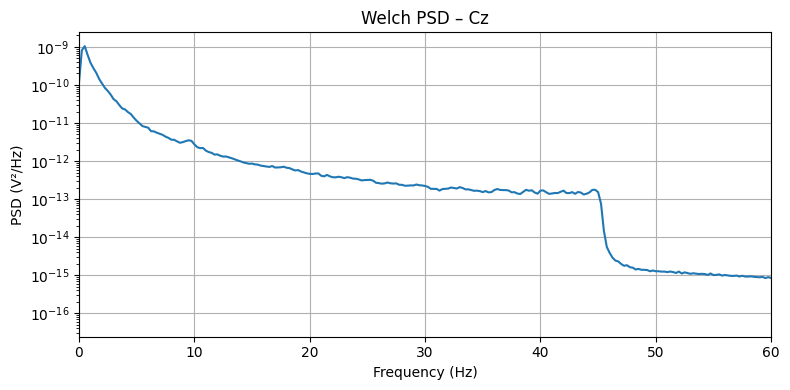

In [16]:
import os
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, periodogram, windows,spectrogram

# ----------------------
# 1. Load data with MNE
# ----------------------
DATASETS = os.path.join(os.getcwd(),'datasets')     # change this
fname = os.path.join(DATASETS, "sub-048_task-eyesclosed_eeg.set")

raw = mne.io.read_raw_eeglab(fname, preload=True)
sfreq = raw.info["sfreq"]           # should be 500.0

# ----------------------
# 2. Pick Cz channel
# ----------------------
raw_cz = raw.copy().pick_channels(["Cz"])
signal = raw_cz.get_data()[0]       # 1D numpy array

# ----------------------
# 3. Remove mean (DC)
# ----------------------
signal = signal - np.mean(signal)

# ------------------------------------------------
# 4. PSD with Welch (recommended over periodogram)
# ------------------------------------------------
WINDOW = 4 * int(sfreq)   # 4‑s window (e.g. 2000 samples at 500 Hz)
NOVERLAP = WINDOW // 2    # 50% overlap
NFFT = WINDOW             # can also use e.g. 2048

win = windows.hamming(WINDOW)

f_psd, pxx = welch(
    signal,
    fs=sfreq,
    window=win,
    nperseg=WINDOW,
    noverlap=NOVERLAP,
    nfft=NFFT,
    scaling="density",
    return_onesided=True
)

plt.figure(figsize=(8, 4))
plt.semilogy(f_psd, pxx)
plt.xlim(0, 60)           # EEG band of interest
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Welch PSD – Cz")
plt.grid(True)
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Spectrogram – Cz')

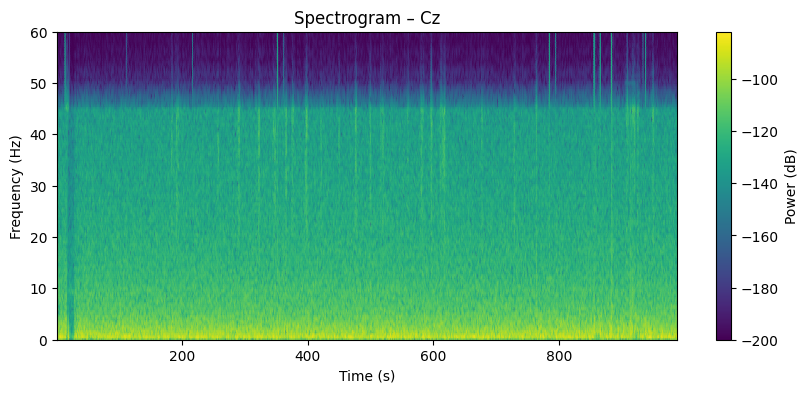

In [17]:

# ----------------------
# 5. Spectrogram
# ----------------------
nperseg = int(2 * sfreq)   # 2‑s windows
noverlap = int(0.5 * nperseg)

f_sxx, t_sxx, Sxx = spectrogram(
    signal,
    fs=sfreq,
    nperseg=nperseg,
    noverlap=noverlap,
    scaling="density",
    mode="psd"
)

Sxx_dB = 10 * np.log10(Sxx + 1e-20)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t_sxx, f_sxx, Sxx_dB, shading="gouraud", cmap="viridis")
plt.ylim(0, 60)            # focus on 0–60 Hz
plt.colorbar(label="Power (dB)")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram – Cz")


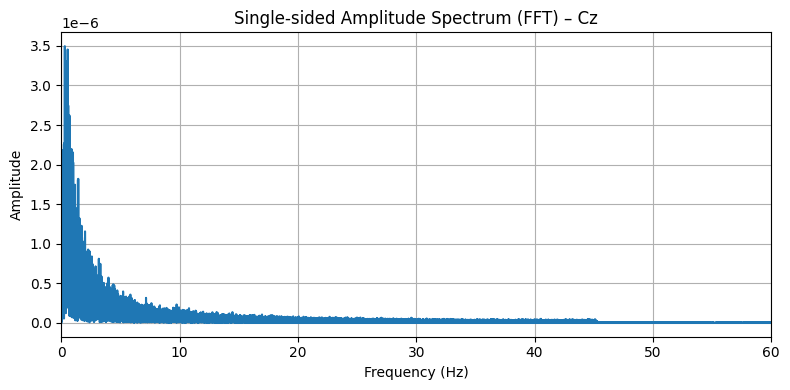

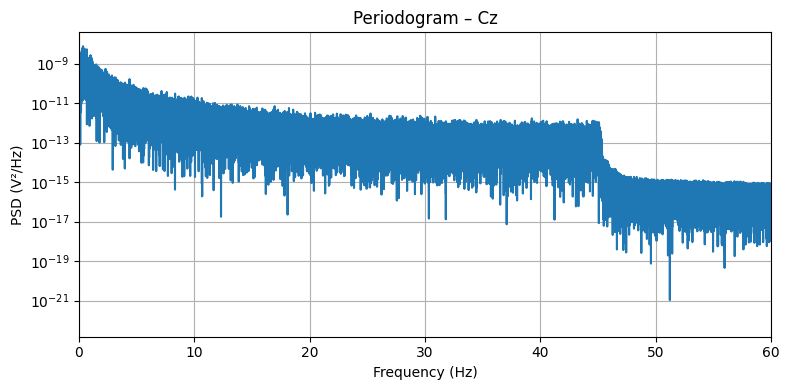

In [18]:
L = len(signal)
Y = np.fft.fft(signal)
P2 = np.abs(Y / L)
P1 = P2[:L // 2 + 1]
P1[1:-1] *= 2            # single-sided
f_fft = sfreq * np.arange(0, L // 2 + 1) / L

plt.figure(figsize=(8, 4))
plt.plot(f_fft, P1)
plt.xlim(0, 60)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("Single-sided Amplitude Spectrum (FFT) – Cz")
plt.grid(True)
plt.tight_layout()
plt.show()

# ===========================
# B. Periodogram (single-sided)
# ===========================
win_full = windows.hamming(L)

f_per, pxx_per = periodogram(
    signal,
    fs=sfreq,
    window=win_full,
    nfft=L,
    scaling="density",
    return_onesided=True
)

plt.figure(figsize=(8, 4))
plt.semilogy(f_per, pxx_per)
plt.xlim(0, 60)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (V²/Hz)")
plt.title("Periodogram – Cz")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
NFFT

2000

In [6]:
win

array([0.08      , 0.08000227, 0.08000909, ..., 0.08000909, 0.08000227,
       0.08      ], shape=(2000,))